## Plots of Greenland basins and zones

In [1]:
import os
import sys

import colorcet as cc
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import numpy as np
import xarray as xr

project_dir = os.path.sep.join(['..'])
sys.path.append(os.path.sep.join([project_dir , 'src']))
from GRL_plotter import plot_greenland_only

In [7]:
base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'evaluations')[0]
data_dir = os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'AuxFiles'])
fig_dir = os.path.sep.join([base_dir, 'figures'])
os.makedirs(fig_dir, exist_ok=True)

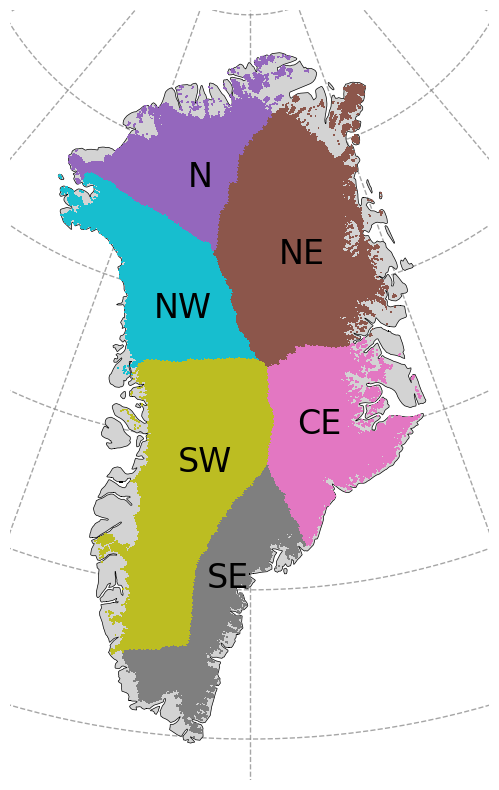

In [9]:
cmap = mcolors.ListedColormap(cc.glasbey_category10[4:10])
colors = [mcolors.to_hex(c) for c in cmap.colors]

gris_data = xr.open_dataset(data_dir + '/GRLmask.nc')['maskbas']
ax, pcm= plot_greenland_only(gris_data, pcolormesh_kwargs={'cmap': cmap}, ocean_color='white', gridlines=True)
fontsize=24
ax.text(0.37, 0.77, f'N', transform=ax.transAxes, fontsize=fontsize, zorder=5)
ax.text(0.56, 0.67, f'NE', transform=ax.transAxes, fontsize=fontsize, zorder=5)
ax.text(0.6, 0.45, f'CE', transform=ax.transAxes, fontsize=fontsize, zorder=5)
ax.text(0.41, 0.25, f'SE', transform=ax.transAxes, fontsize=fontsize, zorder=5)
ax.text(0.35, 0.4, f'SW', transform=ax.transAxes, fontsize=fontsize, zorder=5)
ax.text(0.30, 0.6, f'NW', transform=ax.transAxes, fontsize=fontsize, zorder=5)
ax.figure.savefig(fig_dir+'/basins.png', bbox_inches='tight', transparent=True, pad_inches=0, dpi=300)
plt.show()


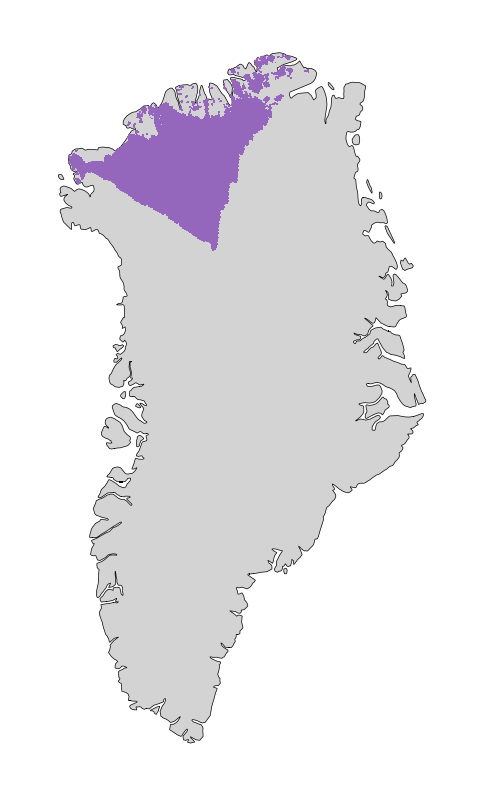

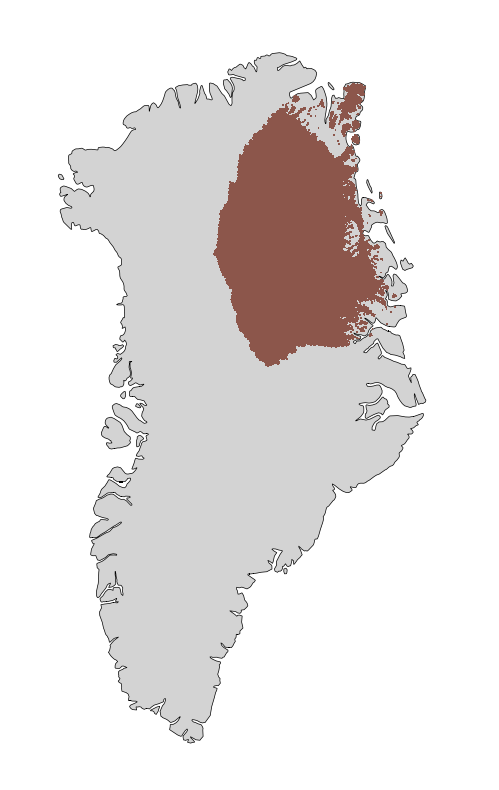

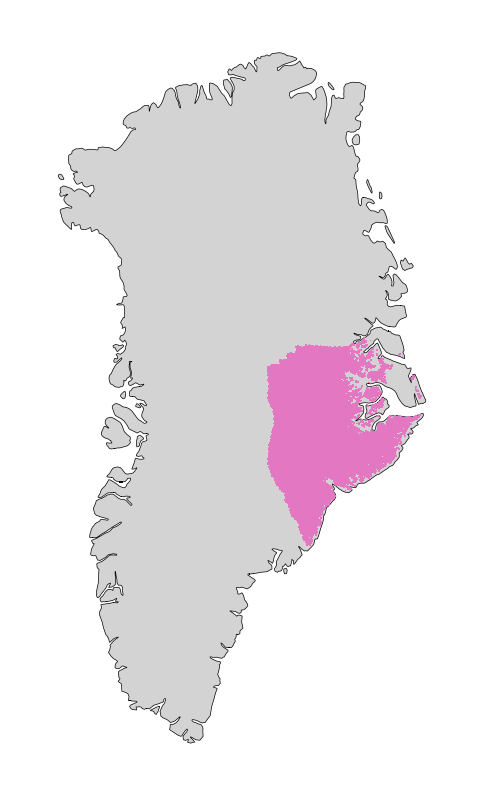

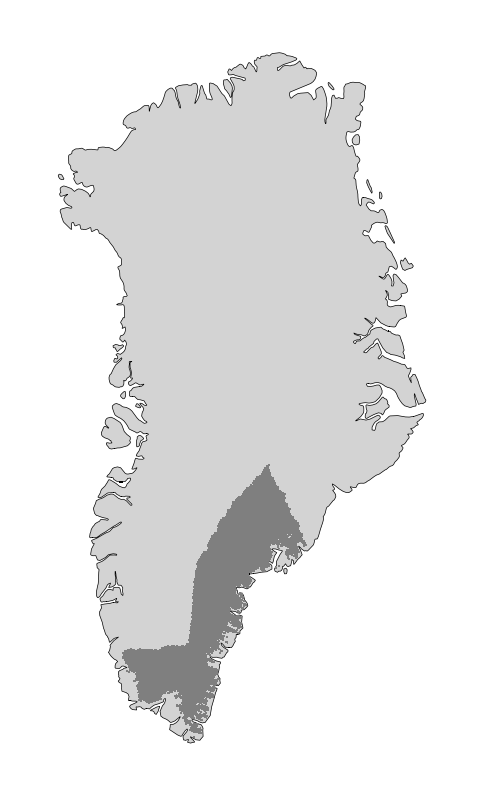

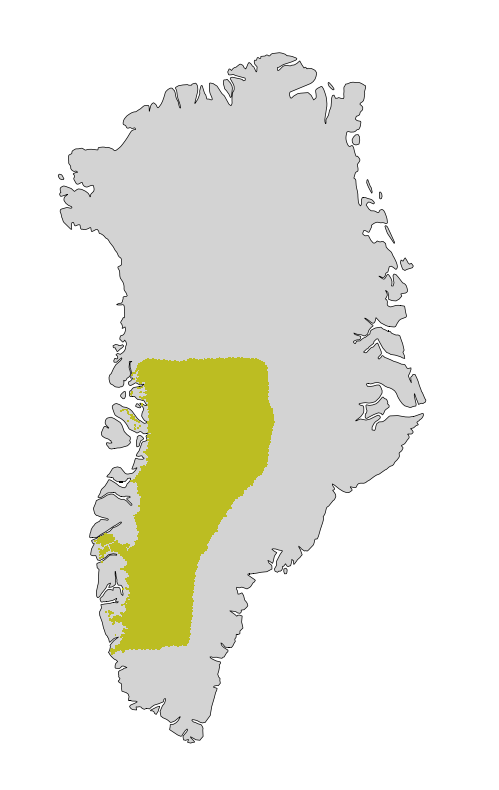

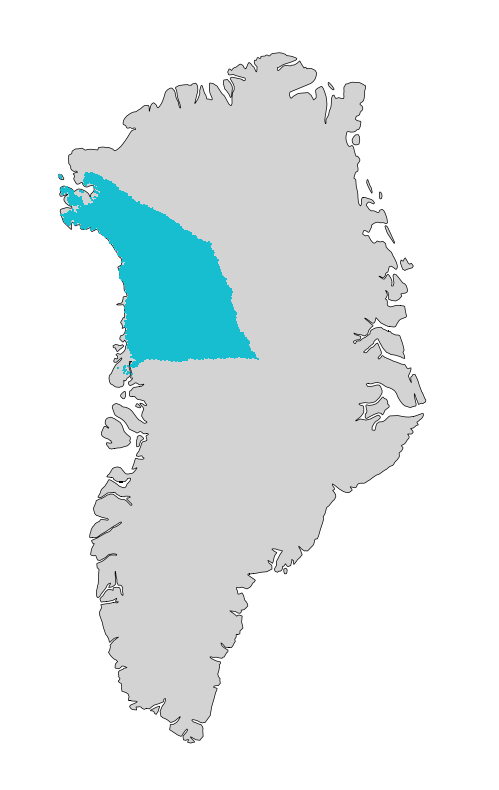

In [10]:
cmap = mcolors.ListedColormap(cc.glasbey_category10[4:10])
colors = [mcolors.to_hex(c) for c in cmap.colors]
for i in range(1,7):
    gris_data = xr.open_dataset(data_dir + '/GRLmask.nc')['maskbas']
    gris_data = gris_data.where(gris_data==i,np.nan)
    ax, pcm = plot_greenland_only(gris_data, pcolormesh_kwargs={'cmap': mcolors.ListedColormap([colors[i-1]])}, ocean_color=None, gridlines=False)
    ax.figure.savefig(fig_dir+f'/basin_{i}.png', bbox_inches='tight', transparent=True, pad_inches=0, dpi=300)
    plt.show()


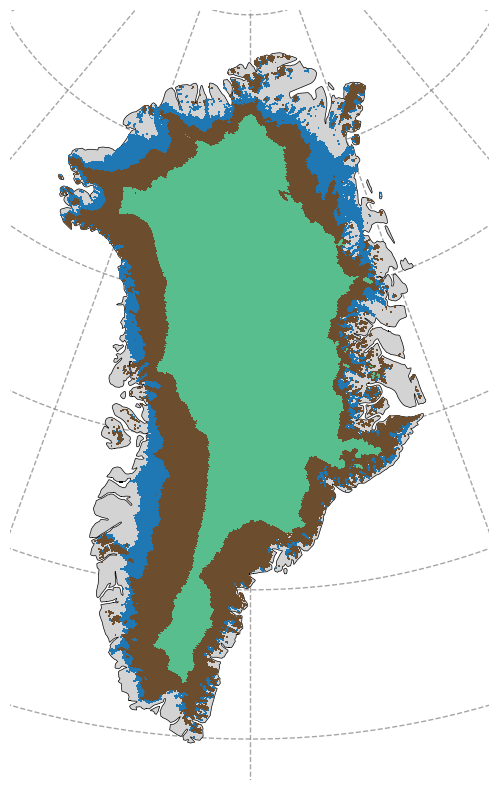

In [11]:
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = [mcolors.to_hex(c) for c in cmap.colors]

gris_data = xr.open_dataset(data_dir + '/GRLzones.nc')['zones']
ax, pcm = plot_greenland_only(gris_data, pcolormesh_kwargs={'cmap': cmap}, gridlines=True, ocean_color='white')
ax.figure.savefig(fig_dir+f'/zones.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()